Treatment start date : 2011-04-01
Derived trperiod     : 424
Complete-case states: 46
Donor count         : 45
Predictor count     : 13

Estimated baseline donor weights:
KENTUCKY        0.478253
NEBRASKA        0.226015
CONNECTICUT     0.109800
NEVADA          0.073810
RHODE ISLAND    0.055656
OHIO            0.045645
NORTH DAKOTA    0.006767
ARIZONA         0.004055
dtype: float64

Estimated predictor weights V:
pct_rural       0.078599
Chg2007_2010    0.077559
p_naics4        0.077127
p_naics3        0.077126
unemp_s_409     0.077074
unemp_s_417     0.076838
unemp_s_401     0.076836
unemp_s_421     0.076819
p12             0.076596
unemp_s_397     0.076532
Chg1999_2006    0.076403
unemp_s_413     0.076253
unemp_s_405     0.076237
dtype: float64

Diagnostics (baseline SCM)
treated_state treatment_start  trperiod  pre_rmspe_baseline  post_rmspe_baseline  post_pre_ratio_baseline  n_donors  n_predictors  n_periods_total  n_periods_pre  n_periods_post
     MISSOURI      2011-04-01       

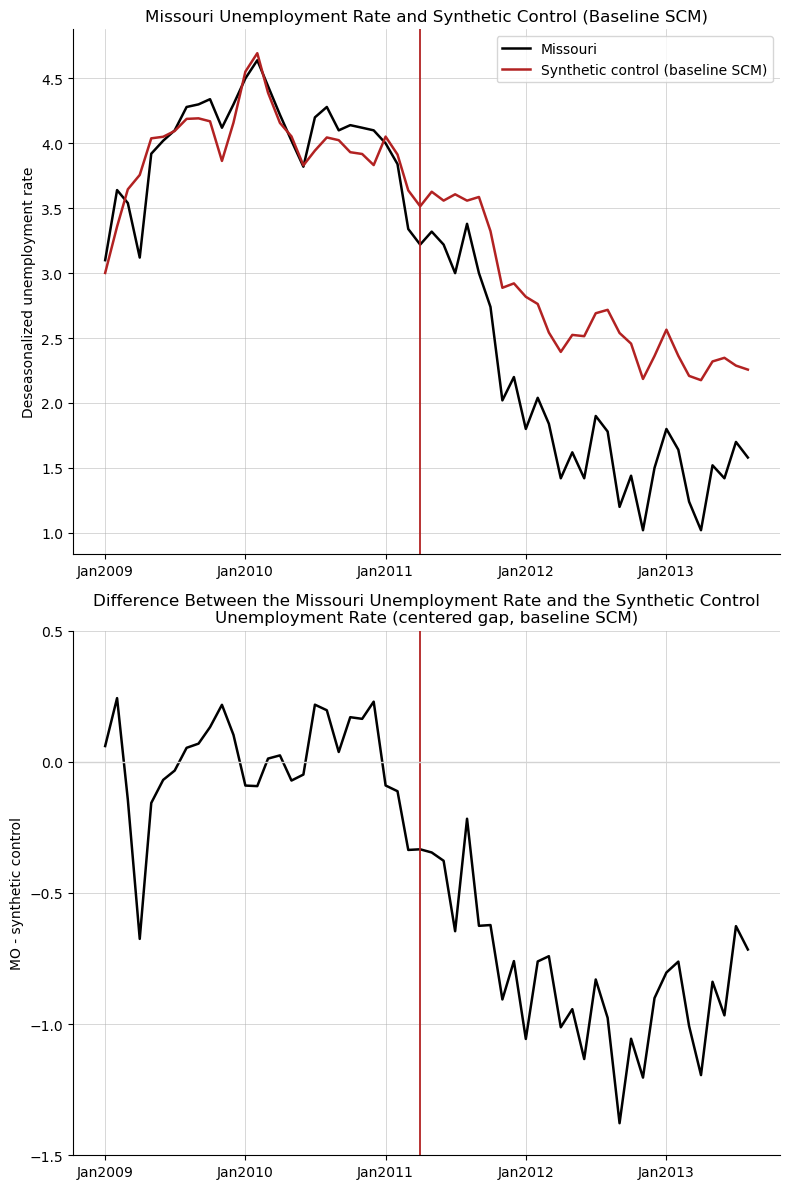

Saved figure: outputs_baseline/baseline_vs_author_paths.pdf


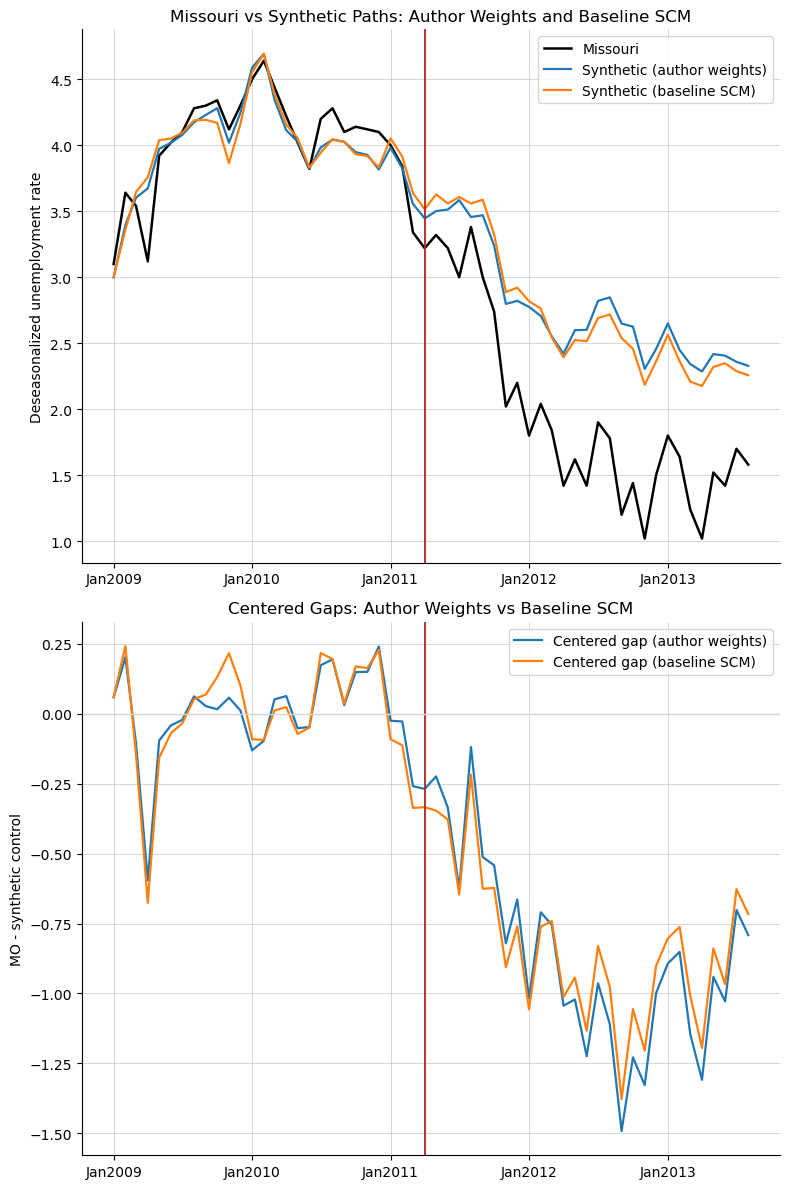


Saved outputs in: outputs_baseline
 - baseline_weights.csv
 - baseline_predictor_weights.csv
 - baseline_df.csv
 - baseline_diagnostics.csv
 - baseline_replication_figure13.pdf
 - time_lookup.csv
 - panel_df_with_unemp_s.csv
 - baseline_vs_author_paths.pdf (if authorweight_df was found)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# 0) Output folder
# ============================================================
OUTPUT_DIR = "outputs_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")

# ============================================================
# 1) Read raw files
# ============================================================
unemp = pd.read_csv("unemp_rate_state.csv")
hpa = pd.read_stata("hpa.dta")
pop = pd.read_stata("pop.dta")

# ============================================================
# 2) Helpers
# ============================================================
def clean_state(s):
    return s.astype(str).str.strip().str.upper()

month_map = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

def solve_w_given_v(X1, X0, v):
    """
    Given predictor weights v, solve donor weights w:
        min_w (X1 - X0 w)' V (X1 - X0 w)
        s.t. w >= 0, sum(w) = 1
    """
    V = np.diag(v)

    def obj(w):
        d = X1 - X0 @ w
        return float(d.T @ V @ d)

    J = X0.shape[1]
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * J
    w0 = np.repeat(1.0 / J, J)

    res = minimize(
        obj,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 200, "ftol": 1e-7, "disp": False}
    )
    if not res.success:
        raise RuntimeError(f"W optimization failed: {res.message}")
    return res.x

def fit_synth_nested(X1, X0, Z1, Z0):
    """
    Standard nested SCM:
      - inner loop: choose donor weights w given predictor weights v
      - outer loop: choose predictor weights v to minimize pretreatment MSPE
    """
    K = X0.shape[0]

    def outer_obj(v_raw):
        v = np.maximum(v_raw, 1e-10)
        v = v / v.sum()
        w = solve_w_given_v(X1, X0, v)
        z_gap = Z1 - Z0 @ w
        return float(np.mean(z_gap ** 2))

    v0 = np.repeat(1.0 / K, K)
    cons = [{"type": "eq", "fun": lambda v: np.sum(v) - 1.0}]
    bounds = [(1e-10, 1.0)] * K

    res_v = minimize(
        outer_obj,
        v0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 120, "ftol": 1e-7, "disp": False}
    )
    if not res_v.success:
        raise RuntimeError(f"V optimization failed: {res_v.message}")

    v_star = np.maximum(res_v.x, 1e-10)
    v_star = v_star / v_star.sum()
    w_star = solve_w_given_v(X1, X0, v_star)

    return v_star, w_star

# ============================================================
# 3) Clean and build time index
# ============================================================
unemp["state"] = clean_state(unemp["state"])
hpa["state"] = clean_state(hpa["state"])
pop["state"] = clean_state(pop["state"])

unemp["month_num"] = unemp["month"].str.lower().map(month_map)
unemp["date"] = pd.to_datetime(dict(year=unemp["year"], month=unemp["month_num"], day=1))

time_lookup = (
    unemp[["year", "month_num", "date"]]
    .drop_duplicates()
    .sort_values(["year", "month_num"])
    .reset_index(drop=True)
)
time_lookup["mo_yr"] = np.arange(1, len(time_lookup) + 1)

unemp = unemp.merge(
    time_lookup[["year", "month_num", "mo_yr"]],
    on=["year", "month_num"],
    how="left"
)

# Keep same broad sample window
unemp = unemp[(unemp["year"] > 2000) & (unemp["year"] < 2015)].copy()

time_lookup.to_csv(os.path.join(OUTPUT_DIR, "time_lookup.csv"), index=False)

# ============================================================
# 4) Build variables used by Figure 13 SCM block
# ============================================================
unemp["p12"] = unemp["p_naics1"] + unemp["p_naics2"]
unemp.loc[unemp["p_naics2"].isna(), "p12"] = unemp.loc[unemp["p_naics2"].isna(), "p_naics1"]

hpa_small = hpa[["state", "year", "index_sa"]].copy()

price_1999 = hpa_small.loc[hpa_small["year"] == 1999, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE1999"})
price_2006 = hpa_small.loc[hpa_small["year"] == 2006, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE2006"})
price_2007 = hpa_small.loc[hpa_small["year"] == 2007, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE2007"})
price_2010 = hpa_small.loc[hpa_small["year"] == 2010, ["state", "index_sa"]].rename(columns={"index_sa": "PRICE2010"})

hpi = (
    price_1999
    .merge(price_2006, on="state", how="inner")
    .merge(price_2007, on="state", how="inner")
    .merge(price_2010, on="state", how="inner")
)

hpi["Chg1999_2006"] = hpi["PRICE2006"] - hpi["PRICE1999"]
hpi["Chg2007_2010"] = hpi["PRICE2010"] - hpi["PRICE2007"]
hpi = hpi[["state", "Chg1999_2006", "Chg2007_2010"]]

pop_small = pop[["state", "pct_rural"]].drop_duplicates()

df = (
    unemp
    .merge(hpi, on="state", how="left")
    .merge(pop_small, on="state", how="left")
    .sort_values(["state", "year", "month_num"])
    .reset_index(drop=True)
)

# ============================================================
# 5) Deseasonalize unemployment rate
# ============================================================
train_means = (
    df.loc[df["year"] < 2006]
    .groupby(["state", "month_num"], as_index=False)["unemp_rate"]
    .mean()
    .rename(columns={"unemp_rate": "seasonal_mean"})
)

df = df.merge(train_means, on=["state", "month_num"], how="left")
df["unemp_rate_ds"] = df["unemp_rate"] - df["seasonal_mean"]
df["unemp_s"] = df["unemp_rate_ds"]

df.to_csv(os.path.join(OUTPUT_DIR, "panel_df_with_unemp_s.csv"), index=False)

# ============================================================
# 6) Sample restriction
# ============================================================
drop_states = {"FLORIDA", "ARKANSAS", "MICHIGAN", "SOUTH CAROLINA", "GEORGIA"}
treated_state = "MISSOURI"
treatment_start = pd.Timestamp("2011-04-01")

synth_df = df.loc[~df["state"].isin(drop_states)].copy()
synth_df = synth_df[(synth_df["mo_yr"] >= 397) & (synth_df["mo_yr"] <= 452)].copy()

# derive treatment period from exact date
tr_matches = synth_df.loc[synth_df["date"] == treatment_start, "mo_yr"].drop_duplicates()
if len(tr_matches) != 1:
    raise ValueError(
        f"Expected exactly one mo_yr for treatment_start={treatment_start.date()}, got {tr_matches.tolist()}"
    )
trperiod = int(tr_matches.iloc[0])

print("Treatment start date :", treatment_start.date())
print("Derived trperiod     :", trperiod)

# ============================================================
# 7) Predictor design
# IMPORTANT:
# We exclude post-treatment anchors because treatment starts in April 2011.
# ============================================================
anchor_static = 409
anchor_unemp = [397, 401, 405, 409, 413, 417, 421]

static_cols = ["pct_rural", "Chg1999_2006", "Chg2007_2010", "p12", "p_naics3", "p_naics4"]

static_block = (
    synth_df.loc[synth_df["mo_yr"] == anchor_static, ["state"] + static_cols]
    .drop_duplicates(subset=["state"])
    .set_index("state")
)

dyn_block = (
    synth_df.loc[synth_df["mo_yr"].isin(anchor_unemp), ["state", "mo_yr", "unemp_s"]]
    .pivot(index="state", columns="mo_yr", values="unemp_s")
)
dyn_block.columns = [f"unemp_s_{c}" for c in dyn_block.columns]

X = static_block.join(dyn_block, how="inner").sort_index()

# pre-treatment path
pre_df = synth_df.loc[synth_df["mo_yr"] < trperiod, ["state", "mo_yr", "unemp_s"]].copy()
pre_wide = pre_df.pivot(index="mo_yr", columns="state", values="unemp_s").sort_index()

# complete-case filter
x_complete = X.dropna().index.tolist()
z_complete = pre_wide.columns[~pre_wide.isna().any(axis=0)].tolist()
common_states = sorted(set(x_complete).intersection(z_complete))

if treated_state not in common_states:
    raise ValueError("MISSOURI not in complete-case sample.")

X = X.loc[common_states]
pre_wide = pre_wide[common_states]

donor_states = [s for s in common_states if s != treated_state]
predictor_names = X.columns.tolist()

print("Complete-case states:", len(common_states))
print("Donor count         :", len(donor_states))
print("Predictor count     :", len(predictor_names))

# treated / donor matrices
X1 = X.loc[treated_state].values.astype(float)
X0 = X.loc[donor_states].T.values.astype(float)

Z1 = pre_wide[treated_state].values.astype(float)
Z0 = pre_wide[donor_states].values.astype(float)

# ============================================================
# 8) Estimate baseline SCM weights
# ============================================================
v_star, w_star = fit_synth_nested(X1, X0, Z1, Z0)

baseline_weights = pd.Series(w_star, index=donor_states).sort_values(ascending=False)
baseline_predictor_weights = pd.Series(v_star, index=predictor_names).sort_values(ascending=False)

print("\nEstimated baseline donor weights:")
print(baseline_weights[baseline_weights > 1e-6])

print("\nEstimated predictor weights V:")
print(baseline_predictor_weights[baseline_predictor_weights > 1e-6])

baseline_weights.to_csv(os.path.join(OUTPUT_DIR, "baseline_weights.csv"))
baseline_predictor_weights.to_csv(os.path.join(OUTPUT_DIR, "baseline_predictor_weights.csv"))

# ============================================================
# 9) Construct baseline_df over full kept window
# ============================================================
full_wide = (
    synth_df.loc[:, ["state", "mo_yr", "date", "unemp_s"]]
    .pivot_table(index=["mo_yr", "date"], columns="state", values="unemp_s")
    .sort_index()
)

baseline_df = full_wide.reset_index().copy()
baseline_df["synthetic_baseline"] = baseline_df[donor_states].values @ w_star
baseline_df["treated"] = baseline_df[treated_state]
baseline_df["gap_raw_baseline"] = baseline_df["treated"] - baseline_df["synthetic_baseline"]

pre_mean_gap_baseline = baseline_df.loc[
    baseline_df["mo_yr"] < trperiod, "gap_raw_baseline"
].mean()

baseline_df["gap_centered_baseline"] = (
    baseline_df["gap_raw_baseline"] - pre_mean_gap_baseline
)

baseline_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_df.csv"), index=False)

# ============================================================
# 10) Diagnostics
# ============================================================
pre_rmspe_baseline = np.sqrt(np.mean(
    baseline_df.loc[baseline_df["mo_yr"] < trperiod, "gap_centered_baseline"] ** 2
))
post_rmspe_baseline = np.sqrt(np.mean(
    baseline_df.loc[baseline_df["mo_yr"] >= trperiod, "gap_centered_baseline"] ** 2
))

baseline_diagnostics = pd.DataFrame([{
    "treated_state": treated_state,
    "treatment_start": treatment_start,
    "trperiod": trperiod,
    "pre_rmspe_baseline": pre_rmspe_baseline,
    "post_rmspe_baseline": post_rmspe_baseline,
    "post_pre_ratio_baseline": post_rmspe_baseline / pre_rmspe_baseline if pre_rmspe_baseline > 0 else np.nan,
    "n_donors": len(donor_states),
    "n_predictors": len(predictor_names),
    "n_periods_total": len(baseline_df),
    "n_periods_pre": int((baseline_df["mo_yr"] < trperiod).sum()),
    "n_periods_post": int((baseline_df["mo_yr"] >= trperiod).sum()),
}])

baseline_diagnostics.to_csv(os.path.join(OUTPUT_DIR, "baseline_diagnostics.csv"), index=False)

print("\nDiagnostics (baseline SCM)")
print(baseline_diagnostics.to_string(index=False))

# ============================================================
# 11) Plot baseline Figure 13 style
# ============================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

xticks = pd.to_datetime([
    "2009-01-01",
    "2010-01-01",
    "2011-01-01",
    "2012-01-01",
    "2013-01-01"
])
xlabels = [d.strftime("Jan%Y") for d in xticks]

# top: levels
ax1.plot(baseline_df["date"], baseline_df["treated"],
         label="Missouri", color="black", linewidth=1.8)
ax1.plot(baseline_df["date"], baseline_df["synthetic_baseline"],
         label="Synthetic control (baseline SCM)", color="firebrick", linewidth=1.8)
ax1.axvline(treatment_start, color="firebrick", linewidth=1.3)

ax1.set_title("Missouri Unemployment Rate and Synthetic Control (Baseline SCM)")
ax1.set_ylabel("Deseasonalized unemployment rate")
ax1.legend()
ax1.grid(True, linewidth=0.5, alpha=0.7)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.tick_params(axis="x", labelbottom=True)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xlabels)

# bottom: centered gap
ax2.plot(baseline_df["date"], baseline_df["gap_centered_baseline"],
         color="black", linewidth=1.8)
ax2.axvline(treatment_start, color="firebrick", linewidth=1.3)
ax2.axhline(0, color="lightgray", linewidth=1)

ax2.set_title(
    "Difference Between the Missouri Unemployment Rate and the Synthetic Control\n"
    "Unemployment Rate (centered gap, baseline SCM)"
)
ax2.set_ylabel("MO - synthetic control")
ax2.set_ylim(-1.5, 0.5)
ax2.set_yticks(np.arange(-1.5, 0.51, 0.5))
ax2.grid(True, linewidth=0.5, alpha=0.7)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="x", labelbottom=True)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xlabels)

plt.tight_layout()
save_fig(fig, "baseline_replication_figure13.pdf")
plt.show()

# ============================================================
# 12) Compare author vs baseline paths, if author outputs exist
# ============================================================
author_df_path = os.path.join("outputs_authorweight", "authorweight_df.csv")
author_weights_path = os.path.join("outputs_authorweight", "author_weights.csv")

if os.path.exists(author_df_path):
    authorweight_df = pd.read_csv(author_df_path)
    authorweight_df["date"] = pd.to_datetime(authorweight_df["date"])

    needed_cols = ["mo_yr", "date", "synthetic_author", "gap_centered_author"]
    missing_author_cols = [c for c in needed_cols if c not in authorweight_df.columns]
    if missing_author_cols:
        print(f"Skipping author comparison plot. Missing columns: {missing_author_cols}")
    else:
        compare_df = baseline_df[
            ["mo_yr", "date", "treated", "synthetic_baseline", "gap_centered_baseline"]
        ].merge(
            authorweight_df[needed_cols],
            on=["mo_yr", "date"],
            how="left"
        )

        compare_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_vs_author_paths.csv"), index=False)

        fig, (ax1, ax2) = plt.subplots(
            2, 1,
            figsize=(8, 12),
            sharex=True,
            gridspec_kw={"height_ratios": [1, 1]}
        )

        # top
        ax1.plot(compare_df["date"], compare_df["treated"],
                 label="Missouri", color="black", linewidth=1.8)
        ax1.plot(compare_df["date"], compare_df["synthetic_author"],
                 label="Synthetic (author weights)", linewidth=1.6)
        ax1.plot(compare_df["date"], compare_df["synthetic_baseline"],
                 label="Synthetic (baseline SCM)", linewidth=1.6)
        ax1.axvline(treatment_start, color="firebrick", linewidth=1.3)

        ax1.set_title("Missouri vs Synthetic Paths: Author Weights and Baseline SCM")
        ax1.set_ylabel("Deseasonalized unemployment rate")
        ax1.legend()
        ax1.grid(True, linewidth=0.5, alpha=0.7)
        ax1.spines["top"].set_visible(False)
        ax1.spines["right"].set_visible(False)
        ax1.tick_params(axis="x", labelbottom=True)
        ax1.set_xticks(xticks)
        ax1.set_xticklabels(xlabels)

        # bottom
        ax2.plot(compare_df["date"], compare_df["gap_centered_author"],
                 label="Centered gap (author weights)", linewidth=1.6)
        ax2.plot(compare_df["date"], compare_df["gap_centered_baseline"],
                 label="Centered gap (baseline SCM)", linewidth=1.6)
        ax2.axvline(treatment_start, color="firebrick", linewidth=1.3)
        ax2.axhline(0, color="lightgray", linewidth=1)

        ax2.set_title("Centered Gaps: Author Weights vs Baseline SCM")
        ax2.set_ylabel("MO - synthetic control")
        ax2.legend()
        ax2.grid(True, linewidth=0.5, alpha=0.7)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.tick_params(axis="x", labelbottom=True)
        ax2.set_xticks(xticks)
        ax2.set_xticklabels(xlabels)

        plt.tight_layout()
        save_fig(fig, "baseline_vs_author_paths.pdf")
        plt.show()

# ============================================================
# 13) Done
# ============================================================
print("\nSaved outputs in:", OUTPUT_DIR)
print(" - baseline_weights.csv")
print(" - baseline_predictor_weights.csv")
print(" - baseline_df.csv")
print(" - baseline_diagnostics.csv")
print(" - baseline_replication_figure13.pdf")
print(" - time_lookup.csv")
print(" - panel_df_with_unemp_s.csv")
print(" - baseline_vs_author_paths.pdf (if authorweight_df was found)")